In [1]:
import pandas as pd
df = pd.read_csv("german_credit.csv")

In [2]:
df

,Creditability,Account Balance,Duration of Credit Mths,Payment Status of Previous Credit,Purpose,Credit Amount,Value of Savings and Stocks,Length of current employment,Instalment per cent,Sex and Marital Status,...,Duration in Current address,Most valuable available asset,Age,Concurrent Credits,Type of apartment,No of Credits at this Bank,Occupation,No of dependents,Telephone,Foreign Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,1,24,2,3,1987,1,3,2,3,...,4,1,21,3,1,1,2,2,1,1
996,0,1,24,2,0,2303,1,5,4,3,...,1,1,45,3,2,1,3,1,1,1
997,0,4,21,4,0,12680,5,5,4,3,...,4,4,30,3,3,1,4,1,2,1
998,0,2,12,2,3,6468,5,1,2,3,...,1,4,52,3,2,1,4,1,2,1


In [3]:
df.isnull().any()

,0
Creditability,False
Account Balance,False
Duration of Credit Mths,False
Payment Status of Previous Credit,False
Purpose,False
Credit Amount,False
Value of Savings and Stocks,False
Length of current employment,False
Instalment per cent,False
Sex and Marital Status,False


In [4]:
df = pd.get_dummies(df, columns=["Payment Status of Previous Credit", "Purpose", "Most valuable available asset", "Occupation", "Telephone", "Foreign Worker", "Sex and Marital Status",'Account Balance'])

In [5]:
df

,Creditability,Duration of Credit Mths,Credit Amount,Value of Savings and Stocks,Length of current employment,Instalment per cent,Guarantors,Duration in Current address,Age,Concurrent Credits,...,Foreign Worker_1,Foreign Worker_2,Sex and Marital Status_1,Sex and Marital Status_2,Sex and Marital Status_3,Sex and Marital Status_4,Account Balance_1,Account Balance_2,Account Balance_3,Account Balance_4
0,1,18,1049,1,2,4,1,4,21,3,...,True,False,False,True,False,False,True,False,False,False
1,1,9,2799,1,3,2,1,2,36,3,...,True,False,False,False,True,False,True,False,False,False
2,1,12,841,2,4,2,1,4,23,3,...,True,False,False,True,False,False,False,True,False,False
3,1,12,2122,1,3,3,1,2,39,3,...,False,True,False,False,True,False,True,False,False,False
4,1,12,2171,1,3,4,1,4,38,1,...,False,True,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,24,1987,1,3,2,1,4,21,3,...,True,False,False,False,True,False,True,False,False,False
996,0,24,2303,1,5,4,2,1,45,3,...,True,False,False,False,True,False,True,False,False,False
997,0,21,12680,5,5,4,1,4,30,3,...,True,False,False,False,True,False,False,False,False,True
998,0,12,6468,5,1,2,1,1,52,3,...,True,False,False,False,True,False,False,True,False,False


In [6]:
from sklearn.feature_selection import SelectKBest,f_regression

In [7]:
X = df.drop(columns="Creditability")

In [8]:
Y = df.loc[:, ["Creditability"]]

In [9]:
f = SelectKBest(score_func=f_regression, k=30).fit(X,Y).get_support()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [10]:
X.columns[f]

Index(['Duration of Credit Mths', 'Credit Amount',
       'Value of Savings and Stocks', 'Length of current employment',
       'Instalment per cent', 'Age', 'Concurrent Credits',
       'No of Credits at this Bank', 'Payment Status of Previous Credit_0',
       'Payment Status of Previous Credit_1',
       'Payment Status of Previous Credit_2',
       'Payment Status of Previous Credit_4', 'Purpose_0', 'Purpose_1',
       'Purpose_3', 'Purpose_6', 'Purpose_8',
       'Most valuable available asset_1', 'Most valuable available asset_4',
       'Occupation_4', 'Telephone_2', 'Foreign Worker_1', 'Foreign Worker_2',
       'Sex and Marital Status_1', 'Sex and Marital Status_2',
       'Sex and Marital Status_3', 'Account Balance_1', 'Account Balance_2',
       'Account Balance_3', 'Account Balance_4'],
      dtype='object')

In [11]:
df = df.loc[:,["Creditability",'Duration of Credit Mths', 'Credit Amount',
       'Value of Savings and Stocks', 'Length of current employment',
       'Instalment per cent', 'Age', 'Concurrent Credits',
       'No of Credits at this Bank', 'Payment Status of Previous Credit_0',
       'Payment Status of Previous Credit_1',
       'Payment Status of Previous Credit_2',
       'Payment Status of Previous Credit_4', 'Purpose_0', 'Purpose_1',
       'Purpose_3', 'Purpose_6', 'Purpose_8',
       'Most valuable available asset_1', 'Most valuable available asset_4',
       'Occupation_4', 'Telephone_2', 'Foreign Worker_1', 'Foreign Worker_2',
       'Sex and Marital Status_1', 'Sex and Marital Status_2',
       'Sex and Marital Status_3', 'Account Balance_1', 'Account Balance_2',
       'Account Balance_3', 'Account Balance_4']]

In [12]:
df

,Creditability,Duration of Credit Mths,Credit Amount,Value of Savings and Stocks,Length of current employment,Instalment per cent,Age,Concurrent Credits,No of Credits at this Bank,Payment Status of Previous Credit_0,...,Telephone_2,Foreign Worker_1,Foreign Worker_2,Sex and Marital Status_1,Sex and Marital Status_2,Sex and Marital Status_3,Account Balance_1,Account Balance_2,Account Balance_3,Account Balance_4
0,1,18,1049,1,2,4,21,3,1,False,...,False,True,False,False,True,False,True,False,False,False
1,1,9,2799,1,3,2,36,3,2,False,...,False,True,False,False,False,True,True,False,False,False
2,1,12,841,2,4,2,23,3,1,False,...,False,True,False,False,True,False,False,True,False,False
3,1,12,2122,1,3,3,39,3,2,False,...,False,False,True,False,False,True,True,False,False,False
4,1,12,2171,1,3,4,38,1,2,False,...,False,False,True,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,24,1987,1,3,2,21,3,1,False,...,False,True,False,False,False,True,True,False,False,False
996,0,24,2303,1,5,4,45,3,1,False,...,False,True,False,False,False,True,True,False,False,False
997,0,21,12680,5,5,4,30,3,1,False,...,True,True,False,False,False,True,False,False,False,True
998,0,12,6468,5,1,2,52,3,1,False,...,True,True,False,False,False,True,False,True,False,False


array([[<Axes: title={'center': 'Creditability'}>,
        <Axes: title={'center': 'Duration of Credit Mths'}>,
        <Axes: title={'center': 'Credit Amount'}>],
       [<Axes: title={'center': 'Value of Savings and Stocks'}>,
        <Axes: title={'center': 'Length of current employment'}>,
        <Axes: title={'center': 'Instalment per cent'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Concurrent Credits'}>,
        <Axes: title={'center': 'No of Credits at this Bank'}>]],
      dtype=object)

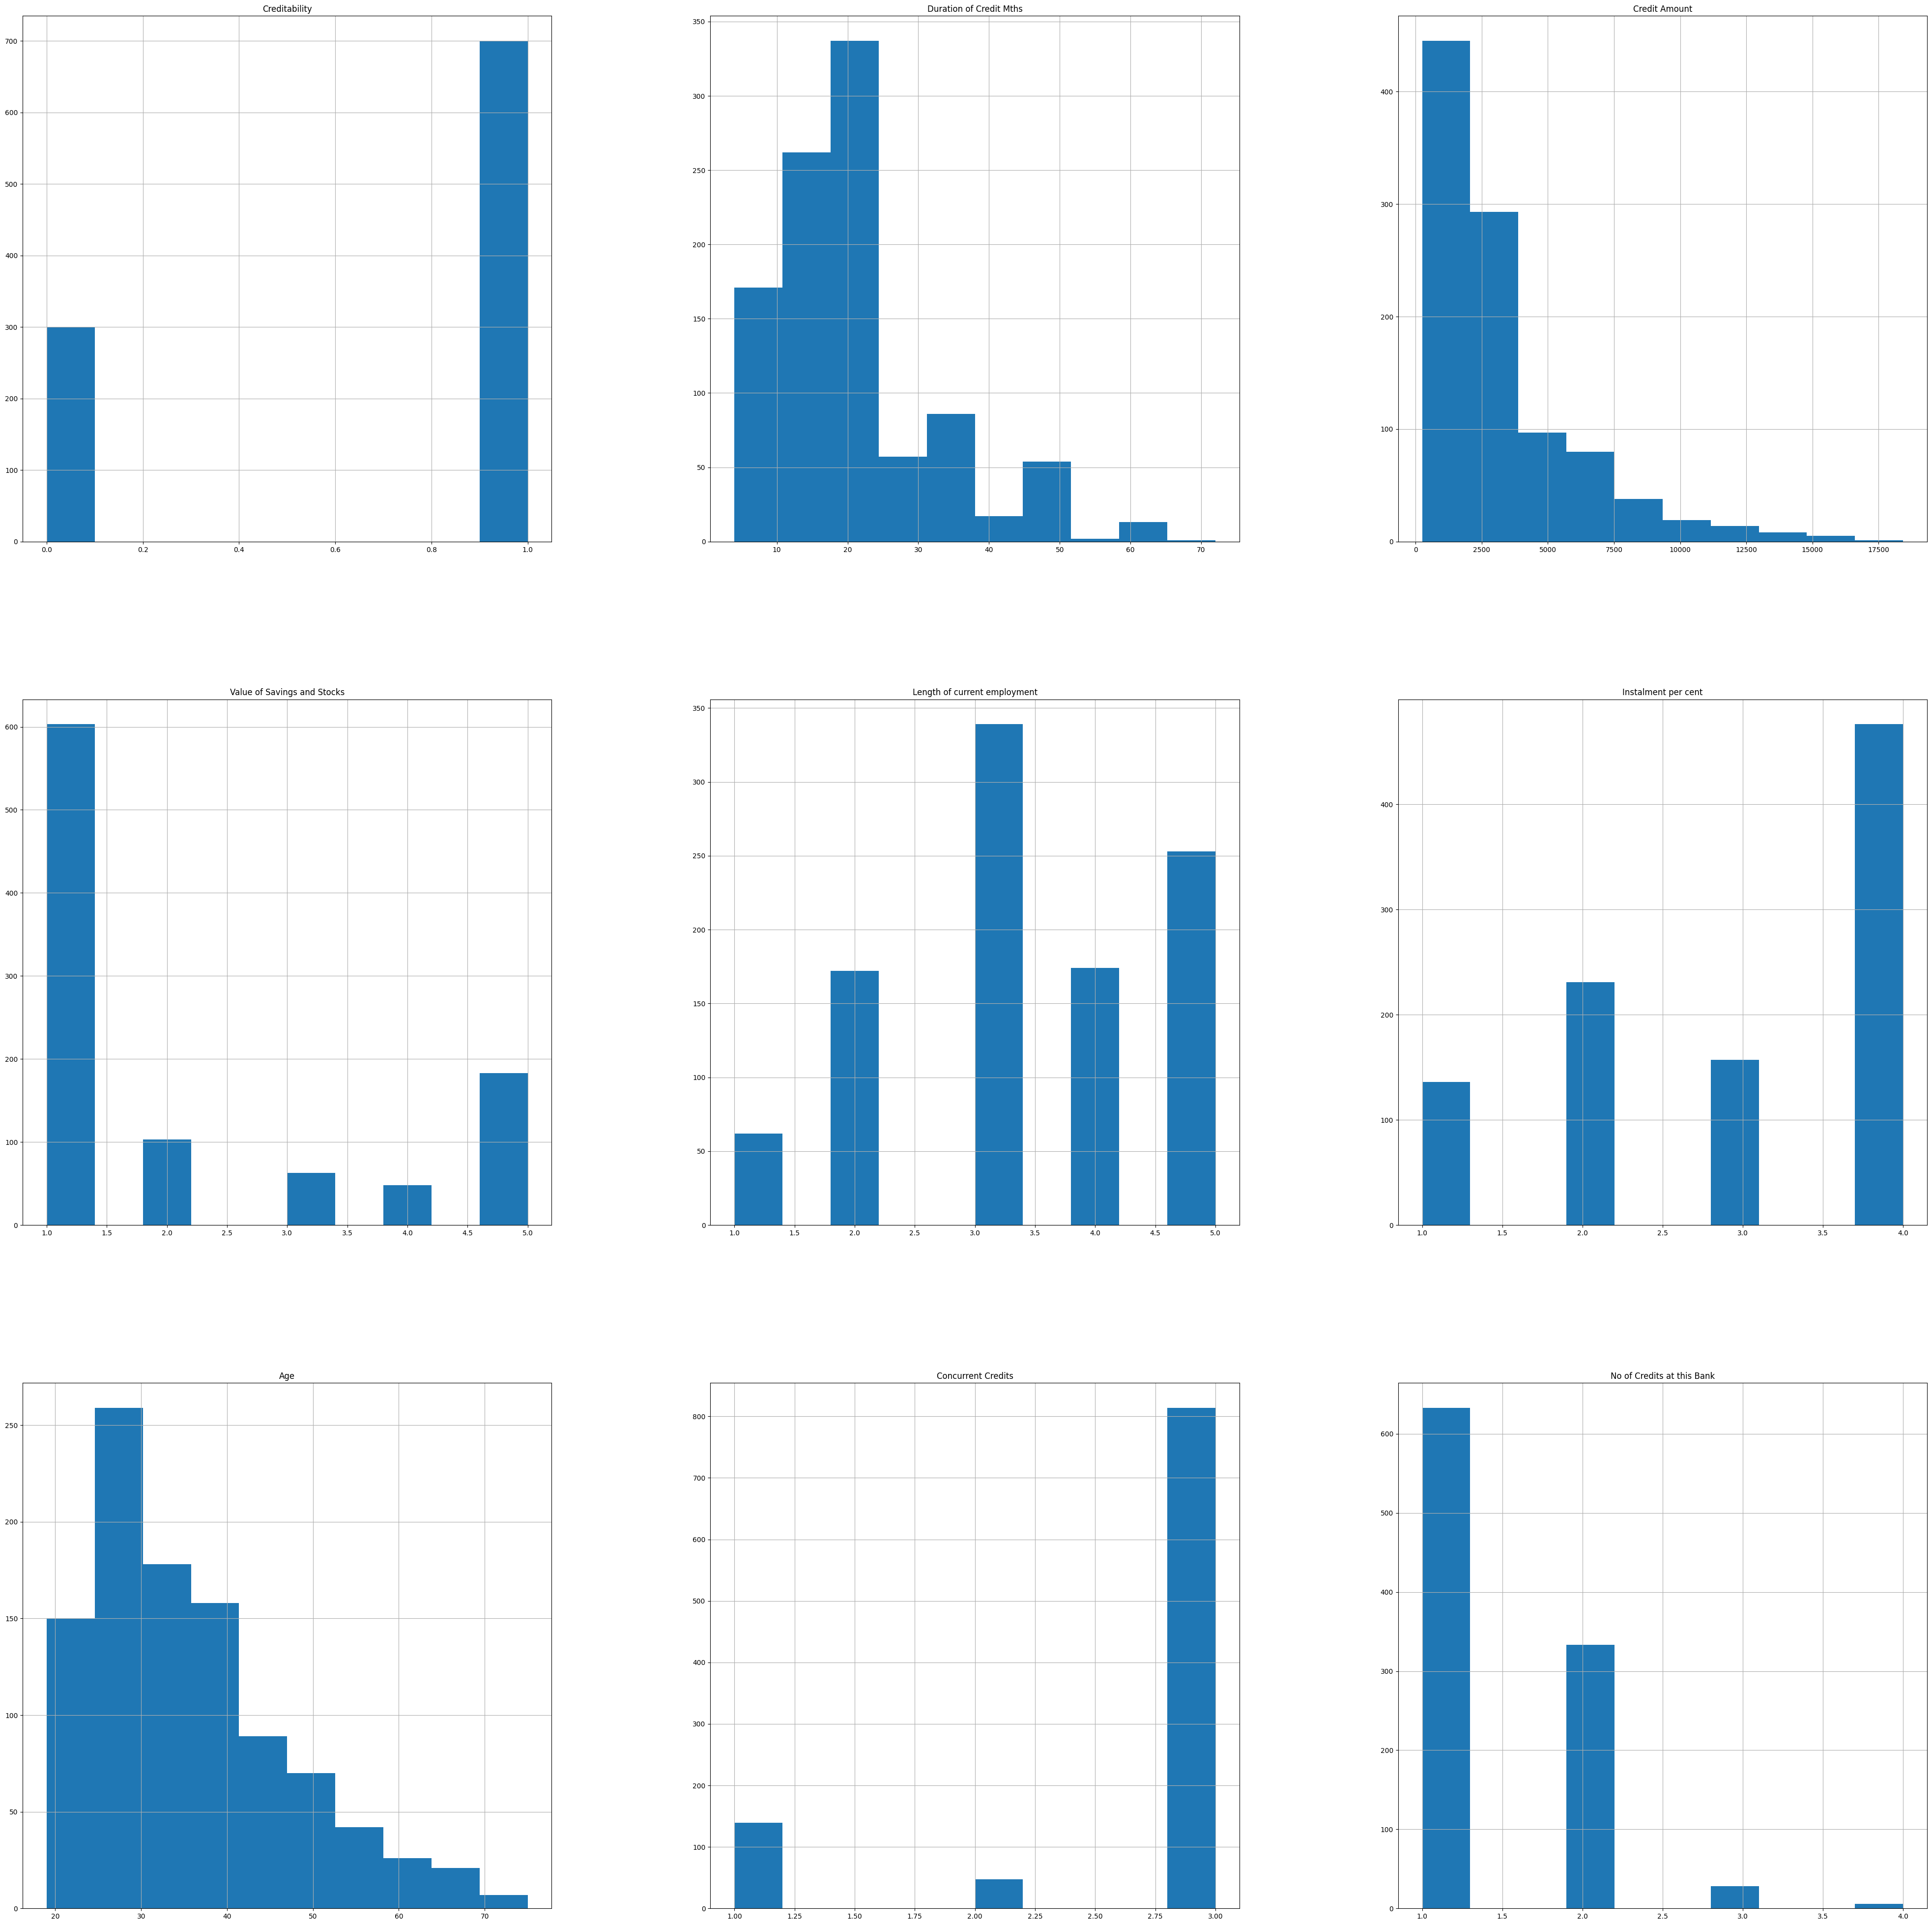

In [13]:
df.hist(figsize=(50,50))

In [14]:
import seaborn as sns

<Axes: >

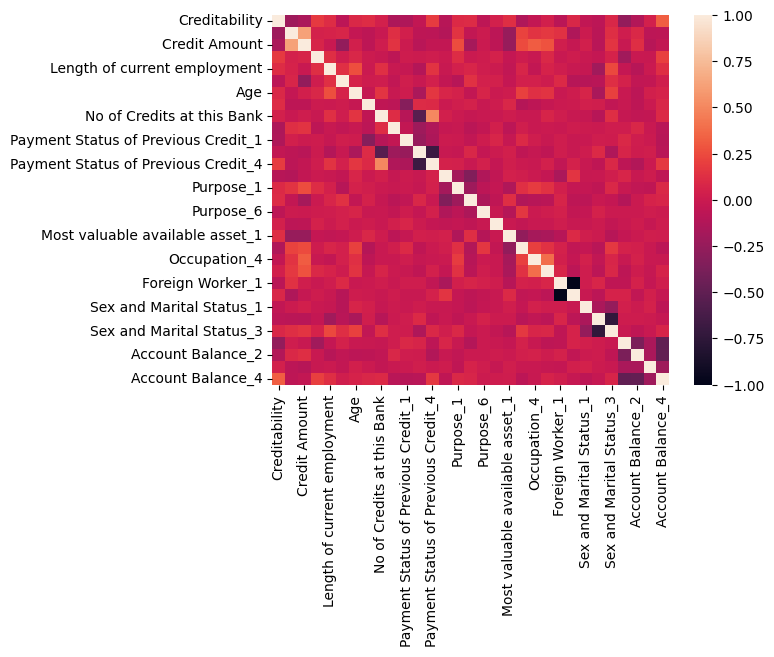

In [15]:
sns.heatmap(df.corr())

<Axes: ylabel='Credit Amount'>

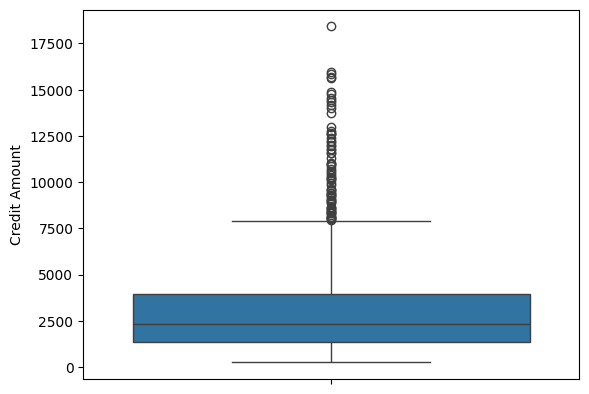

In [16]:
sns.boxplot(data=df["Credit Amount"])

<Axes: xlabel='Creditability', ylabel='count'>

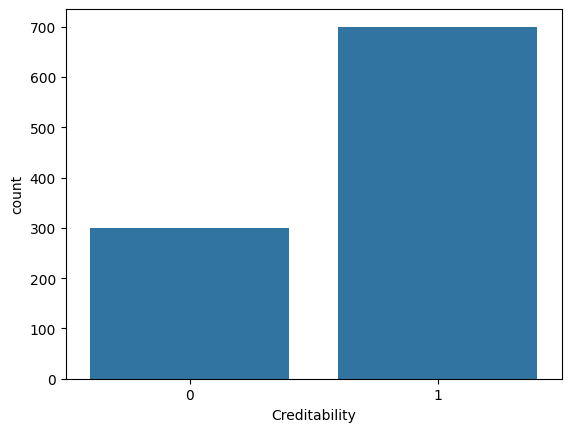

In [17]:
sns.countplot(df,x="Creditability")

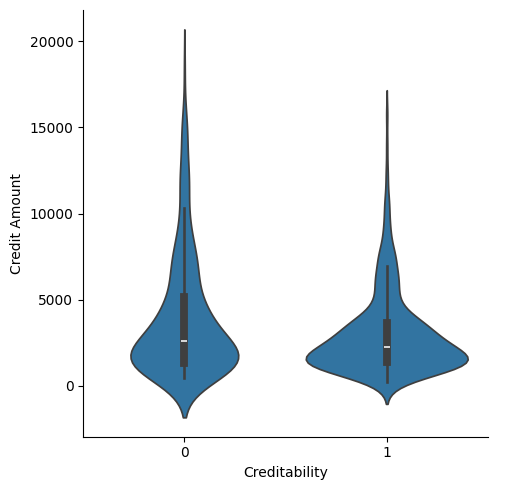

In [20]:
sns.catplot(df,x="Creditability",y="Credit Amount", kind="violin")

In [21]:
from imblearn.over_sampling import SMOTE

In [22]:
X = df.drop(columns="Creditability")
Y = df["Creditability"]

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=1)

In [25]:
Y_train.value_counts()

,count
Creditability,
1,524
0,226


In [26]:
X_train,Y_train = SMOTE(random_state=1).fit_resample(X_train,Y_train)

In [27]:
Y_train.value_counts()

,count
Creditability,
1,524
0,524


In [28]:
from scipy import stats
X_train["Credit Amount"] = stats.zscore(X_train["Credit Amount"])
X_test["Credit Amount"] = stats.zscore(X_test["Credit Amount"])

In [29]:
from sklearn import linear_model

In [30]:
from pandas.core.common import random_state
model = linear_model.LogisticRegression(max_iter=2000,random_state=1)

In [31]:
model.fit(X_train,Y_train)
pred = model.predict(X_test)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, pred)
print(cm)

print("Accuracy is ", (cm[0,0]+cm[1,1])/(sum(sum(cm))))

[[ 43  31]
 [ 31 145]]
Accuracy is  0.752


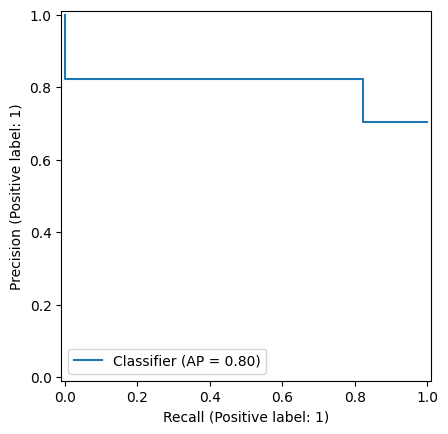

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(Y_test, pred)
plt.show()

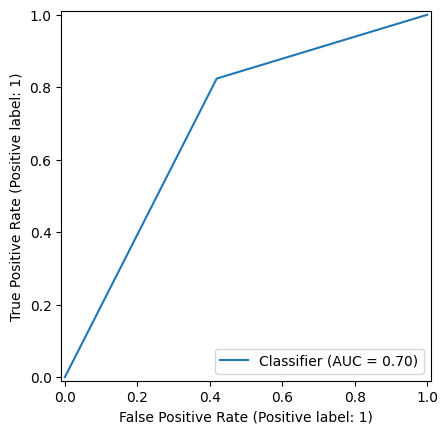

In [33]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(Y_test, pred)
plt.show()

In [34]:
from sklearn import tree

In [35]:
model = tree.DecisionTreeClassifier(random_state=1)

In [36]:
model.fit(X_train,Y_train)
pred = model.predict(X_test)
cm = confusion_matrix(Y_test, pred)
print(cm)
print("Accuracy is ", (cm[0,0]+cm[1,1])/(sum(sum(cm))))

[[ 32  42]
 [ 47 129]]
Accuracy is  0.644


In [37]:
from sklearn import ensemble

In [38]:
model = ensemble.RandomForestClassifier(random_state=1)

In [39]:
model.fit(X_train,Y_train)
pred = model.predict(X_test)
cm = confusion_matrix(Y_test, pred)
print(cm)
print("Accuracy is ", (cm[0,0]+cm[1,1])/(sum(sum(cm))))

[[ 43  31]
 [ 29 147]]
Accuracy is  0.76


In [40]:
fr = model.feature_importances_
print(fr)

for importance, name in sorted(zip(model.feature_importances_,X_train.columns),reverse=True)[:5]:
    print (name, importance)


[0.09434929 0.11346508 0.04773853 0.05659927 0.03988301 0.08363515
 0.03099224 0.02462247 0.006482   0.00629951 0.03192135 0.05420516
 0.01599912 0.01696538 0.0301276  0.00522527 0.00193219 0.0352525
 0.01138401 0.01342599 0.02046586 0.00339652 0.00506888 0.00679974
 0.02065295 0.03837568 0.01857647 0.023243   0.01914395 0.12377185]
Account Balance_4 0.12377185001562553
Credit Amount 0.113465084523131
Duration of Credit Mths 0.09434929221200965
Age 0.08363514982992494
Length of current employment 0.056599269084382425


In [41]:
model = ensemble.GradientBoostingClassifier(random_state=1)

In [42]:
model.fit(X_train,Y_train)
pred = model.predict(X_test)
cm = confusion_matrix(Y_test, pred)
print(cm)
print("Accuracy is ", (cm[0,0]+cm[1,1])/(sum(sum(cm))))

[[ 46  28]
 [ 31 145]]
Accuracy is  0.764


In [43]:
from sklearn import neural_network

In [44]:
model = neural_network.MLPClassifier(random_state=1)

In [45]:
model.fit(X_train,Y_train)
pred = model.predict(X_test)
cm = confusion_matrix(Y_test, pred)
print(cm)
print("Accuracy is ", (cm[0,0]+cm[1,1])/(sum(sum(cm))))

[[ 44  30]
 [ 33 143]]
Accuracy is  0.748


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [46]:
#vif to check collinearity
#1 = not correlated.
#Between 1 and 5 = moderately correlated.
#Greater than 5 = highly correlated.
df = pd.read_csv("german_credit.csv")
df = pd.get_dummies(df, columns=["Payment Status of Previous Credit", "Purpose", "Most valuable available asset", "Occupation", "Telephone", "Foreign Worker", "Sex and Marital Status",'Account Balance'])
X = df.loc[:,["Credit Amount","Age"]]
Y = df.loc[:, ["Creditability"]]
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)


         feature      VIF
0  Credit Amount  2.12627
1            Age  2.12627


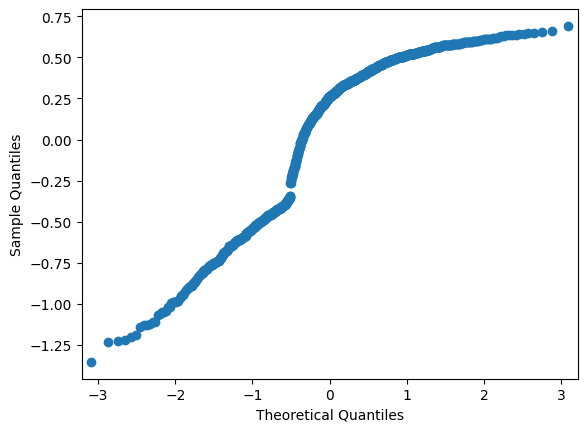

In [47]:
import statsmodels.api as sm
from matplotlib import pyplot as plt
mod_fit = sm.OLS(Y,X).fit()
res = mod_fit.resid # residuals
fig = sm.qqplot(res)
plt.show()

In [48]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
model = ols("Y ~ X", df).fit()
print(model.summary())
anova_results = anova_lm(model)
print('\nANOVA results')
print(anova_results)


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     17.13
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           4.85e-08
Time:                        11:49:17   Log-Likelihood:                -621.72
No. Observations:                1000   AIC:                             1249.
Df Residuals:                     997   BIC:                             1264.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6455      0.049     13.096      0.0

In [49]:
# top2_logreg_german_credit.py
# pip install scikit-learn joblib pandas

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# 1) Load
CSV_PATH = "german_credit.csv"   # <- adjust path if needed
df = pd.read_csv(CSV_PATH)

# 2) One-hot (same set you used previously)
cat_cols = [
    "Payment Status of Previous Credit",
    "Purpose",
    "Most valuable available asset",
    "Occupation",
    "Telephone",
    "Foreign Worker",
    "Sex and Marital Status",
    "Account Balance",
]
cat_cols = [c for c in cat_cols if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# 3) Split X/y
y = df["Creditability"].astype(int)
X = df.drop(columns=["Creditability"])

# 4) Train/test split (reproducible)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 5) Pipeline: Select top-2 features -> Logistic Regression
pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=2)),
    ("lr", LogisticRegression(max_iter=2000, random_state=42))
])

# 6) Train
pipe.fit(X_train, y_train)

# 7) What are the top-2 features?
selector = pipe.named_steps["select"]
mask = selector.get_support()
top2_features = X_train.columns[mask]
print("Top 2 features selected:", list(top2_features))

# 8) Evaluate
y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("\nAccuracy:", round(acc, 4))
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=4))

# 9) Save model
joblib.dump({"pipeline": pipe, "top2_features": list(top2_features)}, "credit_top2_lr.joblib")
print("\nSaved -> credit_top2_lr.joblib")

# 10) Load and test on a few samples
artifact = joblib.load("credit_top2_lr.joblib")
pipe_loaded = artifact["pipeline"]

sample_idx = np.arange(min(5, len(X_test)))
X_sample = X_test.iloc[sample_idx]
y_sample = y_test.iloc[sample_idx]

pred_sample = pipe_loaded.predict(X_sample)
proba_sample = pipe_loaded.predict_proba(X_sample)[:, 1]

print("\nSample predictions (first 5 rows of test):")
for i, (p, pr, yt) in enumerate(zip(pred_sample, proba_sample, y_sample)):
    print(f"Row {i}: pred={p} (P[g]≈{pr:.3f}) | true={yt}")




Top 2 features selected: ['Account Balance_1', 'Account Balance_4']

Accuracy: 0.7
Confusion matrix:
 [[  0  75]
 [  0 175]]

Classification report:
               precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        75
           1     0.7000    1.0000    0.8235       175

    accuracy                         0.7000       250
   macro avg     0.3500    0.5000    0.4118       250
weighted avg     0.4900    0.7000    0.5765       250


Saved -> credit_top2_lr.joblib

Sample predictions (first 5 rows of test):
Row 0: pred=1 (P[g]≈0.866) | true=0
Row 1: pred=1 (P[g]≈0.866) | true=1
Row 2: pred=1 (P[g]≈0.866) | true=1
Row 3: pred=1 (P[g]≈0.510) | true=0
Row 4: pred=1 (P[g]≈0.866) | true=1


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
# one_cell_credit_gradio.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
import joblib
import gradio as gr

# 1) Load dataset
df = pd.read_csv("german_credit.csv")

# Example categorical one-hot encoding
cat_cols = [
    "Payment Status of Previous Credit",
    "Purpose",
    "Most valuable available asset",
    "Occupation",
    "Telephone",
    "Foreign Worker",
    "Sex and Marital Status",
    "Account Balance",
]
cat_cols = [c for c in cat_cols if c in df.columns]
df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

# 2) Split features/target
y = df["Creditability"].astype(int)
X = df.drop(columns=["Creditability"])
all_feature_cols = list(X.columns)

# 3) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4) Build pipeline: top-2 features + Logistic Regression
pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif, k=2)),
    ("lr", LogisticRegression(max_iter=2000, random_state=42))
])
pipe.fit(X_train, y_train)

# 5) Extract top 2 features
selector = pipe.named_steps["select"]
mask = selector.get_support()
top2_features = X_train.columns[mask]
print("Top 2 features selected:", list(top2_features))

# 6) Save artifact (optional, but keeps structure)
joblib.dump({
    "pipeline": pipe,
    "top2_features": list(top2_features),
    "all_feature_cols": all_feature_cols
}, "credit_top2_lr.joblib")

# 7) Define Gradio interface
def predict_with_two(f1, f2):
    # Build a full row with zeros
    row = pd.DataFrame([np.zeros(len(all_feature_cols))], columns=all_feature_cols)
    # Fill the two features
    row[top2_features[0]] = f1
    row[top2_features[1]] = f2
    # Predict
    pred = pipe.predict(row)[0]
    prob = pipe.predict_proba(row)[0, 1]
    return f"Prediction: {pred} (1=Good, 0=Bad), P(Good)={prob:.3f}"

demo = gr.Interface(
    fn=predict_with_two,
    inputs=[gr.Number(label=top2_features[0]), gr.Number(label=top2_features[1])],
    outputs="text",
    title="German Credit Prediction (Top 2 Features)",
    description=f"Enter values for: {top2_features[0]} and {top2_features[1]}."
)

# 8) Launch app
demo.launch()



Top 2 features selected: ['Account Balance_1', 'Account Balance_4']
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a303adbd499632367b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [51]:
# one_cell_credit_gradio.py
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib
import gradio as gr

# 1) Load dataset
df = pd.read_csv("german_credit.csv")

# 2) Pick only Age and Credit Amount columns
# Change these names if your CSV uses slightly different column names
age_col = "Age (years)"
credit_col = "Credit Amount"

# Auto-fix common alternative names
for c in df.columns:
    if c.lower().strip() in ["age", "age (years)", "age_years"]:
        age_col = c
    if c.lower().strip() in ["credit amount", "credit_amount", "creditamount"]:
        credit_col = c

# 3) Features and target
X = df[[age_col, credit_col]].copy()
y = df["Creditability"].astype(int)

# 4) Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 5) Build model
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, random_state=42))
])

pipe.fit(X_train, y_train)

# 6) Check accuracy
test_acc = pipe.score(X_test, y_test)
print("Using features:", [age_col, credit_col])
print("Test Accuracy:", round(test_acc, 4))

# 7) Save model
joblib.dump({
    "pipeline": pipe,
    "feature_cols": [age_col, credit_col]
}, "credit_age_amount_lr.joblib")

# 8) Prediction function
def predict_creditability(age, credit_amount):
    row = pd.DataFrame([[age, credit_amount]], columns=[age_col, credit_col])
    pred = pipe.predict(row)[0]
    prob = pipe.predict_proba(row)[0, 1]
    label = "Good" if pred == 1 else "Bad"
    return f"Prediction: {label} (1=Good, 0=Bad), P(Good) = {prob:.3f}"

# 9) Gradio interface
demo = gr.Interface(
    fn=predict_creditability,
    inputs=[
        gr.Number(label=age_col, value=35),
        gr.Number(label=credit_col, value=2000)
    ],
    outputs="text",
    title="German Credit Prediction using Age and Credit Amount",
    description="Enter Age and Credit Amount to predict creditability."
)

# 10) Launch
demo.launch()

Using features: ['Age', 'Credit Amount']
Test Accuracy: 0.732
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8c48e4c94cb2c4eec.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [52]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import joblib

# Load dataset
df = pd.read_csv("german_credit.csv")

# Detect column names automatically
age_col = None
credit_col = None

for c in df.columns:
    if "age" in c.lower():
        age_col = c
    if "credit" in c.lower() and "amount" in c.lower():
        credit_col = c

print("Using columns:", age_col, credit_col)

# Features
X = df[[age_col, credit_col]]
y = df["Creditability"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Pipeline
model = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000))
])

# Train
model.fit(X_train, y_train)

# Accuracy
acc = model.score(X_test, y_test)
print("Test Accuracy:", acc)

# Save model
joblib.dump({
    "model": model,
    "age_col": age_col,
    "credit_col": credit_col
}, "credit_model.joblib")

print("Model saved as credit_model.joblib")

Using columns: Age Credit Amount
Test Accuracy: 0.732
Model saved as credit_model.joblib


In [53]:
import joblib
import pandas as pd
import gradio as gr

# Load model
artifact = joblib.load("credit_model.joblib")

model = artifact["model"]
age_col = artifact["age_col"]
credit_col = artifact["credit_col"]

# Prediction function
def predict_credit(age, credit_amount):

    data = pd.DataFrame([[age, credit_amount]],
                        columns=[age_col, credit_col])

    pred = model.predict(data)[0]
    prob = model.predict_proba(data)[0][1]

    label = "Good Credit" if pred == 1 else "Bad Credit"

    return f"{label} | Probability of Good Credit: {prob:.3f}"

# Gradio UI
demo = gr.Interface(
    fn=predict_credit,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Credit Amount")
    ],
    outputs="text",
    title="German Credit Prediction",
    description="Predict creditability using Age and Credit Amount"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8bb99799f45c0399d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
